# 5.4 数据基础 (Data Fundamentals)

> **课时**: 约1课时 | **难度**: ⭐⭐ | **标签**: `数据清洗` `特征缩放` `数据集划分` `预处理`

---

## 📚 本节目标

- 掌握数据清洗的一般过程（缺失值、异常值、重复值）
- 掌握特征缩放方法（标准化 Z-Score、归一化 Min-Max）
- 理解训练集、验证集、测试集的划分及原因
- 能够完成端到端的数据预处理流程

> **核心理念**: "Garbage In, Garbage Out" — 数据质量决定了模型质量的上限。


## 一、数据清洗的一般过程

数据清洗是机器学习中最耗时但最重要的步骤之一。统计显示，数据科学家通常花费 **60%-80%** 的时间在数据准备上。

### 1.1 数据清洗流程总览

```
原始数据
  │
  ├──▶ 缺失值处理 ──▶ 填充/删除
  ├──▶ 重复值处理 ──▶ 去重
  ├──▶ 异常值处理 ──▶ 检测/修正/删除
  ├──▶ 数据类型转换 ──▶ 类型一致化
  └──▶ 一致性检查 ──▶ 格式统一
  │
  ▼
干净数据
```

In [1]:
# 创建一个包含各种"脏数据"的模拟数据集
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# 创建模拟数据
data = {
    'id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'age': [25, 30, np.nan, 35, 28, 45, np.nan, 32, 150, 27, 31, 38],   # 缺失值 + 异常值(150)
    'income': [50000, 60000, 45000, 80000, np.nan, 90000, 55000, 70000, 
              48000, 62000, np.nan, 75000],                              # 缺失值
    'gender': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'm'],  # 不一致
    'city': ['Beijing', 'Shanghai', 'Beijing', 'Shenzhen', 'Shanghai',
             'Beijing', 'Shenzhen', 'Shanghai', 'Beijing', 'Shanghai',
             'Beijing', 'Shanghai'],
    'score': [85, 90, 78, 95, 82, 88, 91, 85, 87, 90, 85, 85]  # 有重复行
}

df = pd.DataFrame(data)
# 故意添加重复行
df = pd.concat([df, df.iloc[[0, 7]].copy()], ignore_index=True)

print("原始数据 (含脏数据):")
print(df.to_string())
print(f"\n数据形状: {df.shape}")

原始数据 (含脏数据):
    id    age   income gender      city  score
0    1   25.0  50000.0      M   Beijing     85
1    2   30.0  60000.0      F  Shanghai     90
2    3    NaN  45000.0      M   Beijing     78
3    4   35.0  80000.0      F  Shenzhen     95
4    5   28.0      NaN      M  Shanghai     82
5    6   45.0  90000.0      F   Beijing     88
6    7    NaN  55000.0      M  Shenzhen     91
7    8   32.0  70000.0      F  Shanghai     85
8    9  150.0  48000.0      M   Beijing     87
9   10   27.0  62000.0      F  Shanghai     90
10  11   31.0      NaN      M   Beijing     85
11  12   38.0  75000.0      m  Shanghai     85
12   1   25.0  50000.0      M   Beijing     85
13   8   32.0  70000.0      F  Shanghai     85

数据形状: (14, 6)


### 1.2 缺失值处理

**检测缺失值**:

```python
df.isnull().sum()       # 每列的缺失值数量
df.isnull().mean()      # 每列的缺失值比例
```

**常见处理方法**:

| 方法 | 代码 | 适用场景 |
|------|------|----------|
| 删除缺失行 | `df.dropna()` | 缺失比例很小 |
| 均值填充 | `df.fillna(df.mean())` | 数值型数据 |
| 中位数填充 | `df.fillna(df.median())` | 有异常值时更稳健 |
| 众数填充 | `df.fillna(df.mode())` | 类别型数据 |
| 前向填充 | `df.fillna(method='ffill')` | 时间序列 |
| 插值填充 | `df.interpolate()` | 有趋势的连续数据 |

In [2]:
# 缺失值处理
print("=== 缺失值检测 ===")
print(f"每列缺失值数量:\n{df.isnull().sum()}")
print(f"\n每列缺失值比例:\n{(df.isnull().mean() * 100).round(1)}")

print("\n=== 缺失值处理: 用中位数填充数值列 ===")
df_clean = df.copy()

# 数值列用中位数填充
for col in ['age', 'income']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    n_filled = df[col].isnull().sum()
    print(f"  {col}: 用中位数 {median_val:.1f} 填充了 {n_filled} 个缺失值")

print(f"\n填充后缺失值: {df_clean.isnull().sum().sum()}")

=== 缺失值检测 ===
每列缺失值数量:
id        0
age       2
income    2
gender    0
city      0
score     0
dtype: int64

每列缺失值比例:
id         0.0
age       14.3
income    14.3
gender     0.0
city       0.0
score      0.0
dtype: float64

=== 缺失值处理: 用中位数填充数值列 ===
  age: 用中位数 31.5 填充了 2 个缺失值
  income: 用中位数 61000.0 填充了 2 个缺失值

填充后缺失值: 0


### 1.3 异常值检测与处理

异常值（Outliers）是明显偏离正常范围的值。常见检测方法：

| 方法 | 描述 | 适用场景 |
|------|------|----------|
| **IQR 法** | 超出 $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ 的值 | 对称/偏态分布 |
| **Z-Score 法** | $|z| > 3$ 的值 | 近似正态分布 |
| **领域知识** | 根据业务常识判断 | 所有场景 |

**IQR 法详解**:

$$IQR = Q_3 - Q_1$$

$$\text{下界} = Q_1 - 1.5 \times IQR, \quad \text{上界} = Q_3 + 1.5 \times IQR$$

In [3]:
# 异常值检测 - IQR 法
print("=== 异常值检测 (IQR法) ===")

for col in ['age', 'income']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"\n  {col}:")
    print(f"    Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"    正常范围: [{lower:.1f}, {upper:.1f}]")
    print(f"    异常值数量: {len(outliers)}")
    if len(outliers) > 0:
        print(f"    异常值: {outliers[col].tolist()}")

# 处理异常值: 将 age=150 替换为中位数
print("\n=== 处理异常值 ===")
age_median = df_clean['age'].median()
outlier_mask = df_clean['age'] > 100  # 领域知识: 年龄不应超过100
print(f"发现 {outlier_mask.sum()} 个年龄异常值，替换为中位数 {age_median:.1f}")
df_clean.loc[outlier_mask, 'age'] = age_median

=== 异常值检测 (IQR法) ===

  age:
    Q1=28.5, Q3=34.2, IQR=5.8
    正常范围: [19.9, 42.9]
    异常值数量: 2
    异常值: [45.0, 150.0]

  income:
    Q1=51250.0, Q3=70000.0, IQR=18750.0
    正常范围: [23125.0, 98125.0]
    异常值数量: 0

=== 处理异常值 ===
发现 1 个年龄异常值，替换为中位数 31.5


### 1.4 重复值处理

In [4]:
# 重复值处理
print("=== 重复值检测 ===")
n_duplicates = df_clean.duplicated().sum()
print(f"重复行数: {n_duplicates}")
if n_duplicates > 0:
    print(f"重复行索引: {df_clean[df_clean.duplicated()].index.tolist()}")
    print(df_clean[df_clean.duplicated(keep=False)].to_string())

# 删除重复值
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"\n去重后数据形状: {df_clean.shape}")
print(df_clean.to_string())

=== 重复值检测 ===
重复行数: 2
重复行索引: [12, 13]
    id   age   income gender      city  score
0    1  25.0  50000.0      M   Beijing     85
7    8  32.0  70000.0      F  Shanghai     85
12   1  25.0  50000.0      M   Beijing     85
13   8  32.0  70000.0      F  Shanghai     85

去重后数据形状: (12, 6)
    id   age   income gender      city  score
0    1  25.0  50000.0      M   Beijing     85
1    2  30.0  60000.0      F  Shanghai     90
2    3  31.5  45000.0      M   Beijing     78
3    4  35.0  80000.0      F  Shenzhen     95
4    5  28.0  61000.0      M  Shanghai     82
5    6  45.0  90000.0      F   Beijing     88
6    7  31.5  55000.0      M  Shenzhen     91
7    8  32.0  70000.0      F  Shanghai     85
8    9  31.5  48000.0      M   Beijing     87
9   10  27.0  62000.0      F  Shanghai     90
10  11  31.0  61000.0      M   Beijing     85
11  12  38.0  75000.0      m  Shanghai     85


In [5]:
# 数据一致性处理: gender 列统一大小写
print("=== 数据一致性处理 ===")
print(f"gender 唯一值（处理前）: {df_clean['gender'].unique().tolist()}")
df_clean['gender'] = df_clean['gender'].str.upper()
print(f"gender 唯一值（处理后）: {df_clean['gender'].unique().tolist()}")

print("\n=== 清洗后的最终数据 ===")
print(df_clean.to_string())
print(f"\n数据质量报告:")
print(f"  总行数: {len(df_clean)}")
print(f"  缺失值: {df_clean.isnull().sum().sum()}")
print(f"  重复值: {df_clean.duplicated().sum()}")
print(f"  数据类型:\n{df_clean.dtypes}")

=== 数据一致性处理 ===
gender 唯一值（处理前）: ['M', 'F', 'm']
gender 唯一值（处理后）: ['M', 'F']

=== 清洗后的最终数据 ===
    id   age   income gender      city  score
0    1  25.0  50000.0      M   Beijing     85
1    2  30.0  60000.0      F  Shanghai     90
2    3  31.5  45000.0      M   Beijing     78
3    4  35.0  80000.0      F  Shenzhen     95
4    5  28.0  61000.0      M  Shanghai     82
5    6  45.0  90000.0      F   Beijing     88
6    7  31.5  55000.0      M  Shenzhen     91
7    8  32.0  70000.0      F  Shanghai     85
8    9  31.5  48000.0      M   Beijing     87
9   10  27.0  62000.0      F  Shanghai     90
10  11  31.0  61000.0      M   Beijing     85
11  12  38.0  75000.0      M  Shanghai     85

数据质量报告:
  总行数: 12
  缺失值: 0
  重复值: 0
  数据类型:
id          int64
age       float64
income    float64
gender     object
city       object
score       int64
dtype: object


## 二、特征缩放 (Feature Scaling)

### 2.1 为什么需要特征缩放？

不同特征的取值范围差异很大，如果不做缩放：

- **距离敏感的算法**（KNN、SVM、K-Means）会被大数值特征主导
- **梯度下降**在不同方向的收敛速度不一致

```
例子: 房价预测

  面积: 50~300 m²
  房间数: 1~10
  距离: 1~50 km
  价格: 100~1000 万

  → 如果不做缩放，价格（数值大）会主导模型！
```

### 2.2 标准化 (Standardization / Z-Score)

将数据转换为均值为 0、标准差为 1 的分布：

$$z = \frac{x - \mu}{\sigma}$$

其中 $\mu$ 是均值，$\sigma$ 是标准差。

**特点**: 不限制范围，保持分布形状，对异常值相对稳健。

**适用**: 大多数机器学习算法（尤其是假设数据正态分布的算法）。

### 2.3 归一化 (Min-Max Scaling)

将数据缩放到 $[0, 1]$ 区间：

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**特点**: 严格限制范围，但对异常值敏感（一个极大值会压缩其他值）。

**适用**: 不假设数据分布的场景（如神经网络输入、图像像素值）。

In [6]:
# 特征缩放对比
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 创建不同尺度的模拟数据
data_scale = np.array([
    [50, 3, 100], [120, 5, 300], [80, 2, 200], [200, 8, 500],
    [60, 4, 150], [300, 10, 800], [90, 3, 250], [150, 6, 400]
], dtype=float)

feature_names = ['面积(m²)', '房间数', '距离(km)']

# 标准化
scaler_std = StandardScaler()
data_std = scaler_std.fit_transform(data_scale)

# 归一化
scaler_mm = MinMaxScaler()
data_mm = scaler_mm.fit_transform(data_scale)

print("=== 标准化 (Z-Score) ===")
print(f"均值: {data_std.mean(axis=0).round(6)}")
print(f"标准差: {data_std.std(axis=0).round(6)}")
print(f"最小值: {data_std.min(axis=0).round(4)}")
print(f"最大值: {data_std.max(axis=0).round(4)}")

print("\n=== 归一化 (Min-Max) ===")
print(f"最小值: {data_mm.min(axis=0)}")
print(f"最大值: {data_mm.max(axis=0)}")
print(f"均值: {data_mm.mean(axis=0).round(4)}")

=== 标准化 (Z-Score) ===
均值: [-0. -0. -0.]
标准差: [1. 1. 1.]
最小值: [-1.031  -1.2155 -1.1138]
最大值: [2.1412 1.8962 2.169 ]

=== 归一化 (Min-Max) ===
最小值: [0. 0. 0.]
最大值: [1. 1. 1.]
均值: [0.325  0.3906 0.3393]


C:\Users\Terry\AppData\Local\Temp\ipykernel_31060\2361741161.py:30: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_31060\2361741161.py:30: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_31060\2361741161.py:30: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_31060\2361741161.py:30: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_31060\2361741161.py:30: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\Terry\AppData\Local\Temp\ipykernel_31060\2361741161.py:30: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) miss

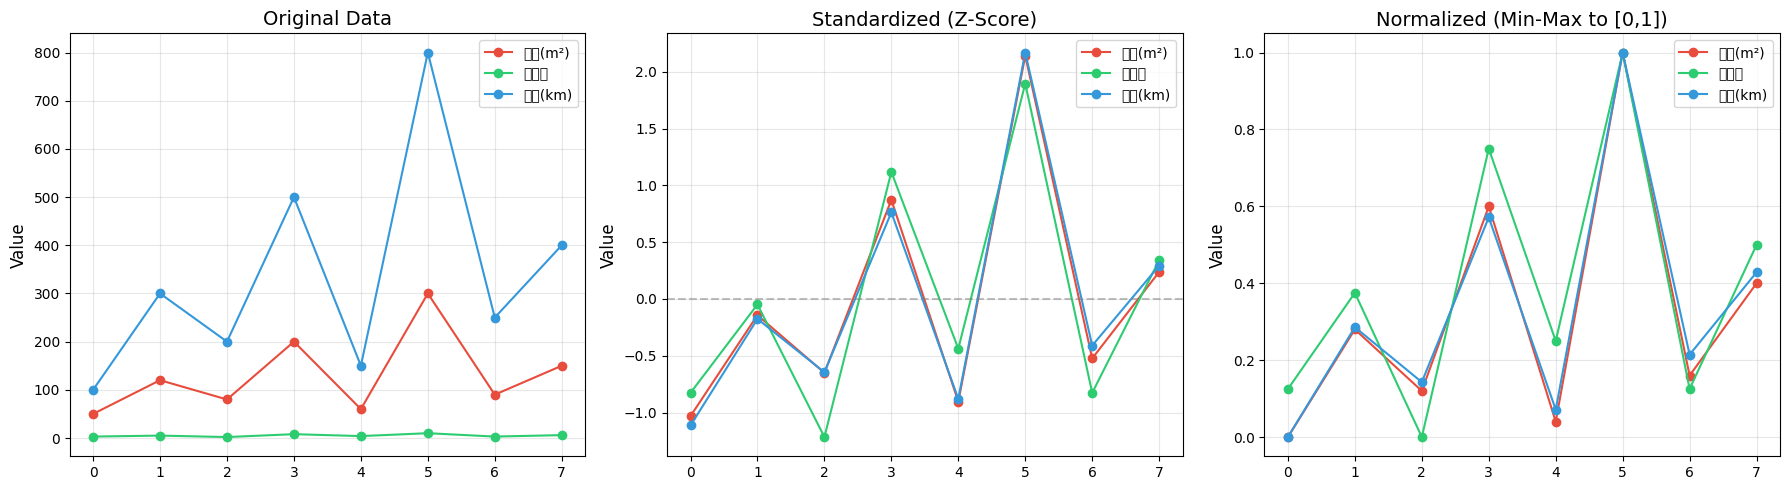

In [15]:
# 可视化特征缩放效果
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_f = ['#e74c3c', '#2ecc71', '#3498db']

# 原始数据
for i, name in enumerate(feature_names):
    axes[0].plot(data_scale[:, i], 'o-', label=name, color=colors_f[i], markersize=6)
axes[0].set_title('Original Data', fontsize=14)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 标准化后
for i, name in enumerate(feature_names):
    axes[1].plot(data_std[:, i], 'o-', label=name, color=colors_f[i], markersize=6)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Standardized (Z-Score)', fontsize=14)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 归一化后
for i, name in enumerate(feature_names):
    axes[2].plot(data_mm[:, i], 'o-', label=name, color=colors_f[i], markersize=6)
axes[2].set_title('Normalized (Min-Max to [0,1])', fontsize=14)
axes[2].set_ylabel('Value', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 标准化 vs 归一化 对比

| 维度 | 标准化 (Z-Score) | 归一化 (Min-Max) |
|------|------------------|-------------------|
| 公式 | $z = \frac{x - \mu}{\sigma}$ | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ |
| 输出范围 | $(-\infty, +\infty)$ (通常 $[-3, 3]$) | $[0, 1]$ |
| 对异常值 | 相对稳健 | 非常敏感 |
| 分布形状 | 保持不变 | 保持不变 |
| 适用算法 | LR, SVM, KNN, K-Means | 神经网络, 图像处理 |

### ⚠️ 重要注意事项

**数据泄漏 (Data Leakage)**: 必须在训练集上 `fit`，在测试集上只 `transform`！

```python
# ✅ 正确做法
scaler.fit(X_train)          # 在训练集上计算均值和标准差
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)     # 用训练集的参数来转换测试集

# ❌ 错误做法 (数据泄漏!)
scaler.fit(X)                # 用全部数据计算参数
X_train = scaler.transform(X_train)    # 测试集的信息泄漏到了训练过程
```

## 三、训练集、验证集、测试集的划分

### 3.1 为什么需要三部分？

| 数据集 | 作用 | 类比 |
|--------|------|------|
| **训练集 (Training Set)** | 用于训练模型、学习参数 | 平时练习题 |
| **验证集 (Validation Set)** | 用于调参、选择模型 | 模拟考试 |
| **测试集 (Test Set)** | 最终评估模型性能 | 期末考试 |

```
完整数据 (100%)
├── 训练集 (60-70%)  → 模型学习参数
├── 验证集 (15-20%)  → 调超参数、模型选择
└── 测试集 (15-20%)  → 最终评估（只用一次！）
```

### 3.2 常见划分比例

| 数据量 | 训练/验证/测试 | 说明 |
|--------|---------------|------|
| 大数据 (>10万) | 98% / 1% / 1% | 数据充足时，验证和测试集不需要很大 |
| 中等数据 (1万-10万) | 70% / 15% / 15% | 最常用的比例 |
| 小数据 (<1万) | 60% / 20% / 20% | 或使用交叉验证 |

### 3.3 为什么不能在测试集上调参？

如果在测试集上反复调参，模型会"记住"测试集的特征，导致测试集上的性能**虚高**，
这叫做**信息泄漏**或**过拟合测试集**。

**正确做法**: 测试集只在最终评估时使用一次。

In [8]:
# 数据集划分示例
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
print(f"完整数据集: {len(X)} 个样本")

# 方法1: 先分出训练集(70%)和临时集(30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 再将临时集分为验证集(15%)和测试集(15%)
# X_temp 占 30%, 验证集占 temp 的 50%, 即总体的 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n=== 数据集划分结果 ===")
print(f"训练集: {len(X_train)} 个样本 ({len(X_train)/len(X)*100:.1f}%)")
print(f"验证集: {len(X_val)} 个样本 ({len(X_val)/len(X)*100:.1f}%)")
print(f"测试集: {len(X_test)} 个样本 ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n各类别分布:")
print(f"  训练集: {np.bincount(y_train)}")
print(f"  验证集: {np.bincount(y_val)}")
print(f"  测试集: {np.bincount(y_test)}")
print(f"\nstratify 参数确保各类别比例一致！")

完整数据集: 150 个样本

=== 数据集划分结果 ===
训练集: 105 个样本 (70.0%)
验证集: 22 个样本 (14.7%)
测试集: 23 个样本 (15.3%)

各类别分布:
  训练集: [35 35 35]
  验证集: [8 7 7]
  测试集: [7 8 8]

stratify 参数确保各类别比例一致！


## 四、数据预处理完整流程

将以上所有步骤整合为一个完整的端到端流程：

```python
# 完整数据预处理流水线

# 1. 加载数据
# 2. 数据探索 (EDA)
# 3. 数据清洗
#    a. 缺失值处理
#    b. 异常值检测与处理
#    c. 重复值删除
#    d. 数据一致性处理
# 4. 特征工程
#    a. 特征缩放
#    b. 特征编码 (类别变量)
# 5. 数据集划分
#    a. 训练集 / 验证集 / 测试集
# 6. 模型训练 & 评估
```

In [9]:
# ============================================
# 完整的数据预处理流程示例
# ============================================
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ---- Step 1: 加载数据 (Titanic 数据集) ----
# 使用 seaborn 内置的 titanic 数据（如果可用），或手动创建
print("Step 1: 加载数据")
titanic_url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
try:
    df_titanic = pd.read_csv(titanic_url)
    print(f"  数据加载成功! 形状: {df_titanic.shape}")
except:
    # 如果网络不可用，使用模拟数据
    print("  网络不可用，使用模拟数据")
    np.random.seed(42)
    n = 500
    df_titanic = pd.DataFrame({
        'Pclass': np.random.choice([1, 2, 3], n, p=[0.2, 0.3, 0.5]),
        'Sex': np.random.choice(['male', 'female'], n, p=[0.6, 0.4]),
        'Age': np.random.normal(30, 10, n),
        'SibSp': np.random.choice([0, 1, 2, 3], n, p=[0.6, 0.25, 0.1, 0.05]),
        'Fare': np.random.exponential(30, n),
        'Survived': np.random.choice([0, 1], n, p=[0.6, 0.4])
    })

print(df_titanic.head())
print(f"\n数据信息:")
print(df_titanic.info())

Step 1: 加载数据
  数据加载成功! 形状: (887, 8)
   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  

数据信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

In [10]:
# ---- Step 2: 数据探索 ----
print("Step 2: 数据探索")
print(f"\n  缺失值统计:")
print(df_titanic.isnull().sum())
print(f"\n  基本统计:")
print(df_titanic.describe().round(2))
print(f"\n  类别分布: {df_titanic['Survived'].value_counts().to_dict()}")

Step 2: 数据探索

  缺失值统计:
Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

  基本统计:
       Survived  Pclass     Age  Siblings/Spouses Aboard  \
count    887.00  887.00  887.00                   887.00   
mean       0.39    2.31   29.47                     0.53   
std        0.49    0.84   14.12                     1.10   
min        0.00    1.00    0.42                     0.00   
25%        0.00    2.00   20.25                     0.00   
50%        0.00    3.00   28.00                     0.00   
75%        1.00    3.00   38.00                     1.00   
max        1.00    3.00   80.00                     8.00   

       Parents/Children Aboard    Fare  
count                   887.00  887.00  
mean                      0.38   32.31  
std                       0.81   49.78  
min               

In [11]:
# ---- Step 3-5: 完整预处理流水线 ----
print("Step 3-5: 完整预处理流水线")

# Step 3: 数据清洗
df_processed = df_titanic.copy()

# 处理缺失值（Age 用中位数填充）
age_median = df_processed['Age'].median()
df_processed['Age'] = df_processed['Age'].fillna(age_median)
print(f"  缺失值处理完成 (Age 中位数填充: {age_median:.1f})")

# Step 4: 特征编码
# 类别变量: Sex → 0/1
le = LabelEncoder()
df_processed['Sex'] = le.fit_transform(df_processed['Sex'])
print(f"  特征编码完成 (Sex: {dict(zip(le.classes_, le.transform(le.classes_)))})")

# 选择特征
feature_cols = ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Fare']
X_all = df_processed[feature_cols].values
y_all = df_processed['Survived'].values

# Step 5: 数据集划分
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f"  数据集划分: 训练{len(X_train)} / 验证{len(X_val)} / 测试{len(X_test)}")

# 特征缩放（在训练集上fit，在验证/测试集上只transform）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print(f"  特征缩放完成 (标准化)")

# Step 6: 训练与评估
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)

# 验证集评估
y_val_pred = model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\n  验证集准确率: {val_acc:.4f} ({val_acc*100:.1f}%)")

# 测试集评估（最终评估）
y_test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"  测试集准确率: {test_acc:.4f} ({test_acc*100:.1f}%)")

print(f"\n=== 测试集分类报告 ===")
print(classification_report(y_test, y_test_pred, target_names=['Not Survived', 'Survived']))

Step 3-5: 完整预处理流水线
  缺失值处理完成 (Age 中位数填充: 28.0)
  特征编码完成 (Sex: {'female': 0, 'male': 1})
  数据集划分: 训练620 / 验证133 / 测试134
  特征缩放完成 (标准化)

  验证集准确率: 0.8120 (81.2%)
  测试集准确率: 0.7836 (78.4%)

=== 测试集分类报告 ===
              precision    recall  f1-score   support

Not Survived       0.80      0.87      0.83        82
    Survived       0.76      0.65      0.70        52

    accuracy                           0.78       134
   macro avg       0.78      0.76      0.77       134
weighted avg       0.78      0.78      0.78       134



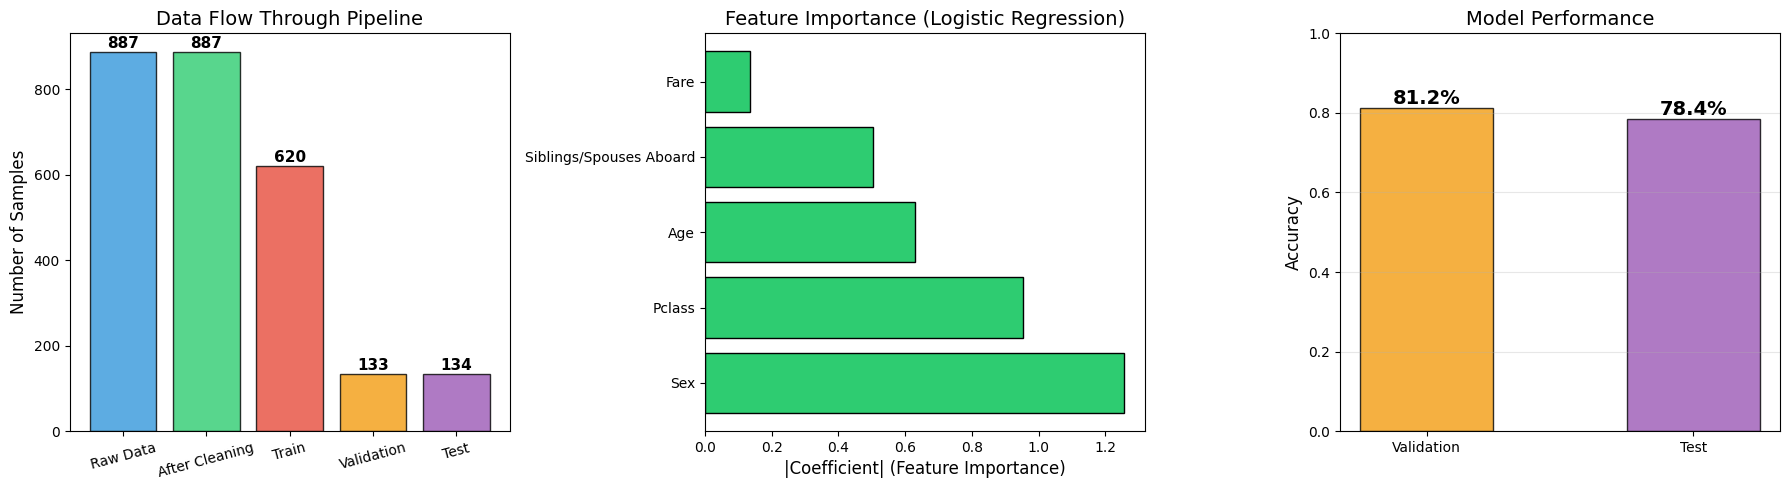

In [12]:
# 可视化数据预处理流程
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左图: 各阶段数据量
stages = ['Raw Data', 'After Cleaning', 'Train', 'Validation', 'Test']
counts = [len(df_titanic), len(df_processed), len(X_train), len(X_val), len(X_test)]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = axes[0].bar(stages, counts, color=colors_bar, edgecolor='black', alpha=0.8)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(count), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Data Flow Through Pipeline', fontsize=14)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# 中图: 特征重要性（模型系数）
importance = np.abs(model.coef_[0])
sorted_idx = np.argsort(importance)[::-1]
axes[1].barh(range(len(feature_cols)), importance[sorted_idx], color='#2ecc71', edgecolor='black')
axes[1].set_yticks(range(len(feature_cols)))
axes[1].set_yticklabels([feature_cols[i] for i in sorted_idx])
axes[1].set_xlabel('|Coefficient| (Feature Importance)', fontsize=12)
axes[1].set_title('Feature Importance (Logistic Regression)', fontsize=14)

# 右图: 验证集 vs 测试集准确率
acc_data = [val_acc, test_acc]
bars2 = axes[2].bar(['Validation', 'Test'], acc_data, color=['#f39c12', '#9b59b6'],
                     edgecolor='black', alpha=0.8, width=0.5)
for bar, acc in zip(bars2, acc_data):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc*100:.1f}%', ha='center', fontsize=14, fontweight='bold')
axes[2].set_ylim(0, 1.0)
axes[2].set_ylabel('Accuracy', fontsize=12)
axes[2].set_title('Model Performance', fontsize=14)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 🏋️ 练习题

### 练习1：概念理解

**Q1**: 为什么在数据清洗时，异常值不一定都要删除？举一个不应该删除异常值的例子。

**Q2**: 解释什么是「数据泄漏」，在特征缩放时如何避免？

**Q3**: 为什么测试集只能使用一次？如果反复在测试集上评估并调参会有什么后果？

**Q4**: 标准化和归一化分别适用于什么场景？如果你有一列包含极端异常值的数据，应该选择哪种方法？

### 练习2：代码实践

**Q5**: 创建一个包含缺失值、异常值和重复值的数据集，然后完成以下清洗步骤：
1. 检测并处理缺失值
2. 使用 IQR 法检测并处理异常值
3. 删除重复行
4. 对数值特征进行标准化
5. 划分训练集(70%)、验证集(15%)、测试集(15%)
6. 训练一个分类模型并评估

In [13]:
# 练习5: 参考答案
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

# 1. 创建含问题数据的数据集
n = 200
X_dirty = pd.DataFrame({
    'feature1': np.random.normal(50, 10, n),
    'feature2': np.random.normal(100, 20, n),
    'feature3': np.random.normal(0, 1, n)
})
y = (X_dirty['feature1'] + X_dirty['feature2'] * 0.5 + np.random.normal(0, 5, n) > 110).astype(int)

# 注入缺失值
missing_idx = np.random.choice(n, 15, replace=False)
X_dirty.loc[missing_idx, 'feature1'] = np.nan

# 注入异常值
X_dirty.loc[n-1, 'feature2'] = 999
X_dirty.loc[n-2, 'feature3'] = -50

# 添加重复行
X_dirty = pd.concat([X_dirty, X_dirty.iloc[:5]], ignore_index=True)
y = np.concatenate([y, y[:5]])

print(f"原始数据: {X_dirty.shape[0]} 行")
print(f"缺失值: {X_dirty.isnull().sum().sum()}")
print(f"重复行: {X_dirty.duplicated().sum()}")

# 2. 清洗
X_clean = X_dirty.copy()

# 缺失值: 中位数填充
X_clean['feature1'] = X_clean['feature1'].fillna(X_clean['feature1'].median())

# 异常值: IQR法
for col in ['feature2', 'feature3']:
    Q1, Q3 = X_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (X_clean[col] < lower) | (X_clean[col] > upper)
    if mask.any():
        X_clean.loc[mask, col] = X_clean[col].median()
        print(f"  修复 {col} 中 {mask.sum()} 个异常值")

# 去重
dup_mask = X_clean.duplicated()
X_clean = X_clean[~dup_mask].reset_index(drop=True)
y_clean = y[~dup_mask]
print(f"\n清洗后: {X_clean.shape[0]} 行, 缺失值: {X_clean.isnull().sum().sum()}")

# 3. 划分数据集
X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean.values, y_clean, test_size=0.3, random_state=42, stratify=y_clean
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 4. 特征缩放
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# 5. 训练 & 评估
model = LogisticRegression(random_state=42)
model.fit(X_train_s, y_train)
print(f"\n验证集准确率: {accuracy_score(y_val, model.predict(X_val_s)):.4f}")
print(f"测试集准确率: {accuracy_score(y_test, model.predict(X_test_s)):.4f}")
print("\n预处理流程完成!")

原始数据: 205 行
缺失值: 16
重复行: 5
  修复 feature2 中 3 个异常值
  修复 feature3 中 2 个异常值

清洗后: 200 行, 缺失值: 0

验证集准确率: 0.8667
测试集准确率: 0.9333

预处理流程完成!


---

## 📌 本节小结

| 知识点 | 要点 |
|--------|------|
| 数据清洗 | 缺失值填充、异常值检测(IQR/Z-Score)、去重、一致性检查 |
| 标准化 | $z = \frac{x - \mu}{\sigma}$，均值0标准差1 |
| 归一化 | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$，缩放到 $[0,1]$ |
| 数据泄漏 | 必须在训练集上 fit，测试集只 transform |
| 数据集划分 | 训练集(学参数) + 验证集(调超参) + 测试集(最终评估) |

---

## 🎉 模块五总结

恭喜完成模块五「机器学习方法范式」的学习！你已经掌握了四种核心学习范式：

| 小节 | 学习范式 | 核心算法 | 关键概念 |
|------|----------|----------|----------|
| 5.1 | 监督学习 | LR, SVM, RF, KNN | 前向/反向传播, 训练/推理 |
| 5.2 | 无监督学习 | K-Means, PCA, t-SNE | 聚类, 降维, 肘部法则 |
| 5.3 | 强化学习 | Q-Learning | MDP, ε-greedy, 探索与利用 |
| 5.4 | 数据基础 | 数据清洗, 特征缩放 | 缺失值, 异常值, 数据集划分 |

**下一步**: 进入 [模块六：深度学习基础](../模块六_深度学习基础/)
